In [86]:
"""Exhaustive feature-subset search for XGBoost on clinical_preprocessed.csv."""
import sys
import warnings
from pathlib import Path

import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report



In [87]:
df = pd.read_csv('../data/clinical/clinical_preprocessed.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2134 entries, 0 to 2133
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PTID                2134 non-null   int64  
 1   VISITYR             2134 non-null   int64  
 2   CDRSUM              2134 non-null   float64
 3   CDRGLOB             2134 non-null   float64
 4   MMSE                2019 non-null   float64
 5   HVLT_DR             1849 non-null   float64
 6   LASSI_A_CR2         1830 non-null   float64
 7   LASSI_B_CR1         1826 non-null   float64
 8   LASSI_B_CR2         1810 non-null   float64
 9   APOE4S              1903 non-null   float64
 10  PTAU_217_CONCNTRTN  672 non-null    float64
 11  AMYLPET             1430 non-null   float64
 12  FL_UDSD             2120 non-null   float64
 13  NACCETPR            1611 non-null   float64
dtypes: float64(12), int64(2)
memory usage: 233.5 KB


In [88]:
REMOVE_FEATURES = ["CDRGLOB", "AMYLPET", "NACCETPR"]
DROP_COLS = ["PTID", "VISITYR", "FL_UDSD"]

In [89]:
diagnosis_order = ['NC', 'SCD', 'Imp Not SCD/MCI',
                   'EMCI', 'LMCI', 'Dementia']
diagnosis_map = {i: label for i, label in enumerate(diagnosis_order)}

diagnosis_map

{0: 'NC', 1: 'SCD', 2: 'Imp Not SCD/MCI', 3: 'EMCI', 4: 'LMCI', 5: 'Dementia'}

In [90]:
list(diagnosis_map.values())

['NC', 'SCD', 'Imp Not SCD/MCI', 'EMCI', 'LMCI', 'Dementia']

In [91]:
def make_model(model='xgb'):
    if model == 'lr':
        return LogisticRegression(max_iter=3000, random_state=42)
    if model == 'rf':
        return RandomForestClassifier(n_estimators=250, random_state=42)
    if model=='xgb':
        return xgb.XGBClassifier(
            n_estimators=100,
            random_state=42,
            objective="multi:softprob",
            eval_metric="mlogloss",
            tree_method="hist",
            n_jobs=4,
        )
    

In [92]:
model_name = 'lr'

In [93]:
REMOVE_FEATURES = ['CDRGLOB','AMYLPET', 'NACCETPR']
df_filter = df.drop(columns=REMOVE_FEATURES).dropna()
df_filter.info()

<class 'pandas.core.frame.DataFrame'>
Index: 591 entries, 6 to 2072
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PTID                591 non-null    int64  
 1   VISITYR             591 non-null    int64  
 2   CDRSUM              591 non-null    float64
 3   MMSE                591 non-null    float64
 4   HVLT_DR             591 non-null    float64
 5   LASSI_A_CR2         591 non-null    float64
 6   LASSI_B_CR1         591 non-null    float64
 7   LASSI_B_CR2         591 non-null    float64
 8   APOE4S              591 non-null    float64
 9   PTAU_217_CONCNTRTN  591 non-null    float64
 10  FL_UDSD             591 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 55.4 KB


In [94]:
features = ['CDRSUM', 'HVLT_DR', 'LASSI_B_CR1']
X = df_filter[features]
y = (df_filter["FL_UDSD"].astype(int) - 1) 
X.head()

,CDRSUM,HVLT_DR,LASSI_B_CR1
6,1.0,8.0,8.0
11,1.5,6.0,8.0
13,0.5,8.0,10.0
18,1.0,7.0,7.0
24,1.5,11.0,12.0


In [95]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

In [96]:
model = make_model(model_name)

In [97]:
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [98]:
cross_validate(model, X, y, groups=df_filter['PTID'],cv=cv, scoring=('f1_macro', 'balanced_accuracy'), return_estimator=True)

{'fit_time': array([0.02562714, 0.01930952, 0.01783228, 0.01795411, 0.01884532]),
 'score_time': array([0.00229025, 0.00211096, 0.00208879, 0.00203228, 0.00213957]),
 'estimator': [LogisticRegression(max_iter=3000, random_state=42),
  LogisticRegression(max_iter=3000, random_state=42),
  LogisticRegression(max_iter=3000, random_state=42),
  LogisticRegression(max_iter=3000, random_state=42),
  LogisticRegression(max_iter=3000, random_state=42)],
 'test_f1_macro': array([0.78534726, 0.60358989, 0.63759297, 0.60307909, 0.66727691]),
 'test_balanced_accuracy': array([0.83183191, 0.64779541, 0.66309524, 0.62331738, 0.67859477])}

In [99]:
results = cross_validate(
    model, X, y,
    groups=df_filter['PTID'],
    cv=cv,
    scoring=('f1_macro', 'balanced_accuracy'),
    return_estimator=True,
)

fold_idx = 0  # pick the fold you want

splits = list(cv.split(X, y, groups=df_filter['PTID']))
train_idx, test_idx = splits[fold_idx]

est = results['estimator'][fold_idx]
y_true = y.iloc[test_idx]
y_pred = est.predict(X.iloc[test_idx])

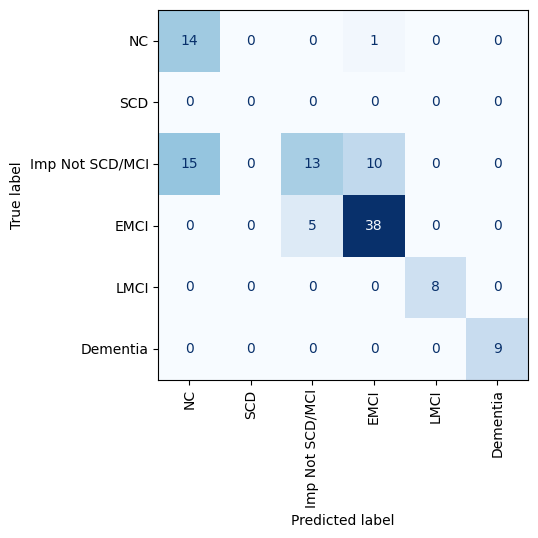

In [100]:
labels = list(diagnosis_map.values())

cm = confusion_matrix(y_true, y_pred, labels=est.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues', colorbar=False)
disp.ax_.tick_params(axis='x', rotation=90)

In [101]:
print(classification_report(y_true, y_pred, labels=est.classes_,
                            target_names=labels, zero_division=0, digits=4))

                 precision    recall  f1-score   support

             NC     0.4828    0.9333    0.6364        15
            SCD     0.0000    0.0000    0.0000         0
Imp Not SCD/MCI     0.7222    0.3421    0.4643        38
           EMCI     0.7755    0.8837    0.8261        43
           LMCI     1.0000    1.0000    1.0000         8
       Dementia     1.0000    1.0000    1.0000         9

       accuracy                         0.7257       113
      macro avg     0.6634    0.6932    0.6545       113
   weighted avg     0.7525    0.7257    0.7054       113



In [102]:
def combine_categories(df: pd.DataFrame, combination_map: dict, target_col: str = 'FL_UDSD') -> pd.DataFrame:
    """
    Combine multiple categories in the target column into single categories.
    
    Args:
        df: Input dataframe
        target_col: Column containing categories to combine
        combination_map: Dictionary where keys are new category names and values are lists of 
                        categories to combine into that new category.
                        Example: {'SCD/Impaired': ['Subjective Cognitive Decline', 'Impaired Not SCD/MCI'],
                                 'Normal/SCD': ['Normal cognition', 'Subjective Cognitive Decline']}
    
    Returns:
        pd.DataFrame: DataFrame with combined categories
    """
    df = df.copy()
    
    # Apply each combination
    for new_category, old_categories in combination_map.items():
        df[target_col] = df[target_col].replace(old_categories, new_category)
    
    return df

In [103]:
SCD_CODE = 2
IMPAIRED_NOT_SCD_CODE = 3
PRE_MCI_CODE = 2

df_combined = df_filter.copy()

df_combined = combine_categories(
    df_combined,
    combination_map={PRE_MCI_CODE: [SCD_CODE, IMPAIRED_NOT_SCD_CODE]},
    target_col='FL_UDSD',
)

# Renumber so codes are contiguous: 1=Normal, 2=Pre-MCI, 3=EMCI, 4=LMCI, 5=Dementia
renumber_map = {1: 1, 2: 2, 4: 3, 5: 4, 6: 5}
df_combined['FL_UDSD'] = df_combined['FL_UDSD'].map(renumber_map)

df_combined['FL_UDSD'].value_counts().sort_index()

FL_UDSD
1     79
2    171
3    218
4     65
5     58
Name: count, dtype: int64

In [104]:
diagnosis_order = ['Normal cognition', 'Pre-MCI', 
                   'Early MCI', 'Late MCI', 'Dementia']
diagnosis_map = {i: label for i, label in enumerate(diagnosis_order)}

diagnosis_map

{0: 'Normal cognition',
 1: 'Pre-MCI',
 2: 'Early MCI',
 3: 'Late MCI',
 4: 'Dementia'}

In [105]:
cv_combined = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
model_combined = make_model(model_name)

In [106]:
features = ['CDRSUM', 'HVLT_DR', 'PTAU_217_CONCNTRTN']
X = df_combined[features]
y = (df_combined["FL_UDSD"].astype(int) - 1) 
X.head()

,CDRSUM,HVLT_DR,PTAU_217_CONCNTRTN
6,1.0,8.0,1.071290
11,1.5,6.0,1.429017
13,0.5,8.0,0.289207
18,1.0,7.0,0.432879
24,1.5,11.0,0.483837


In [107]:
cross_validate(model_combined, X, y, groups=df_filter['PTID'],cv=cv, scoring=('f1_macro', 'balanced_accuracy'), return_estimator=True)

{'fit_time': array([0.01271057, 0.01339817, 0.01224804, 0.01140523, 0.01348591]),
 'score_time': array([0.0021677 , 0.00208807, 0.00208139, 0.00204921, 0.00204444]),
 'estimator': [LogisticRegression(max_iter=3000, random_state=42),
  LogisticRegression(max_iter=3000, random_state=42),
  LogisticRegression(max_iter=3000, random_state=42),
  LogisticRegression(max_iter=3000, random_state=42),
  LogisticRegression(max_iter=3000, random_state=42)],
 'test_f1_macro': array([0.73342831, 0.70019841, 0.77726993, 0.79734827, 0.75387306]),
 'test_balanced_accuracy': array([0.74524526, 0.69498699, 0.77421245, 0.83421781, 0.78728778])}

In [108]:
results = cross_validate(
    model_combined, X, y,
    groups=df_combined['PTID'],
    cv=cv,
    scoring=('f1_macro', 'balanced_accuracy'),
    return_estimator=True,
)

fold_idx = 3  # pick the fold you want

splits = list(cv.split(X, y, groups=df_filter['PTID']))
train_idx, test_idx = splits[fold_idx]

est = results['estimator'][fold_idx]
y_true = y.iloc[test_idx]
y_pred = est.predict(X.iloc[test_idx])

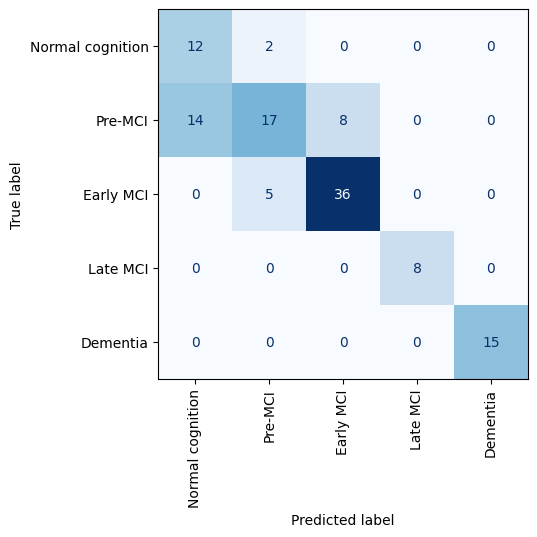

In [109]:
labels = list(diagnosis_map.values())

cm = confusion_matrix(y_true, y_pred, labels=est.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues', colorbar=False)
disp.ax_.tick_params(axis='x', rotation=90)

In [110]:
print(classification_report(y_true, y_pred, labels=est.classes_,
                            target_names=labels, zero_division=0, digits=4))

                  precision    recall  f1-score   support

Normal cognition     0.4615    0.8571    0.6000        14
         Pre-MCI     0.7083    0.4359    0.5397        39
       Early MCI     0.8182    0.8780    0.8471        41
        Late MCI     1.0000    1.0000    1.0000         8
        Dementia     1.0000    1.0000    1.0000        15

        accuracy                         0.7521       117
       macro avg     0.7976    0.8342    0.7973       117
    weighted avg     0.7746    0.7521    0.7451       117

